### 네이버 증권 페이지에서 환율 데이터를 크롤링 해보자

In [1]:
import requests as req
from bs4 import BeautifulSoup as bs

In [8]:
 
res = req.get('https://finance.naver.com/marketindex/' )
res

<Response [200]>

In [9]:
# bs객체화
soup = bs(res.text, 'lxml')
soup

<html><head><script language="javascript" src="/template/head_js.naver?referer=info.finance.naver.com&amp;menu=marketindex&amp;submenu=market"></script>
<script src="https://ssl.pstatic.net/imgstock/static.pc/20260827132721/js/info/jindo.min.ns.1.5.3.euckr.js" type="text/javascript"></script>
<script src="https://ssl.pstatic.net/imgstock/static.pc/20260827132721/js/jindo.1.5.3.element-text-patch.js" type="text/javascript"></script>
</head><body><div class="home_spot_banner">
<a class="notice_link" href="https://stock.naver.com/notice/149">
<img alt="투자에 필요한 다양한 시장지표를 한눈에 확인해 보세요. 기존 증권 서비스는 9월 10일 종료되며, 더 향상된 투자 경험으로 개편됩니다. 자세히보기" height="96" src="https://ssl.pstatic.net/static/nfinance/notice/banner_market_2.png" width="960"/>
</a>
<a class="new_link" href="https://stock.naver.com/market/marketindex">
<span class="blind">새로운 증권 바로가기</span>
</a>
</div>
<div id="container" style="padding-bottom:0px;">
<div class="market_include">
<div class="market_data">
<div class="market1">
<div clas

In [10]:
# iframe 때문에 정보가 나오지 않는다.
soup.select("td.sale")

[]

#### iframe
- 화면에는 존재하는 것처럼 보이지만, 실제 데이터는 다른 서버에 존재하는 경우
- i(internet) frame(창)
- 원래는 iframe이 가벼웠지만 현재는 서버가 발전하면서 iframe이 상대적으로 무거워 져서 잘 안쓴다.
- 하지만 이전부터 있던 페이지들은 새로 구축 하는게 힘들기 때문에 iframe을 계속 쓴다.
- 컨트롤 f누르고 iframe검색후 원하는 부분 나올때까지 엔터 누르면 된다.
- 진짜 서버에 존재하는 내용을 창으로만 보여준다.

In [12]:
# 밑에는 메인주소 + iframe이 가지고 있던 소스값. 아이프레임으로 가는 서브주소
# com까지가 메인주소임. 이건 사이트 주소창에서 com까지 가져온거임
# 서브주소는 f12창에서 찾아온거고.
real_url = "https://finance.naver.com/marketindex/exchangeList.naver"

In [13]:
# 실제 데이터가 존재하는 곳으로 데이터 요청을 다시 해야한다.
res = req.get(real_url)
res

<Response [200]>

In [14]:
# bs 객체화
soup4 = bs(res.text, 'lxml')
soup4

<html lang="ko">
<head>
<title>Npay 증권</title>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="text/javascript" http-equiv="Content-Script-Type"/>
<meta content="text/css" http-equiv="Content-Style-Type"/>
<link href="https://ssl.pstatic.net/imgstock/static.pc/20260827132721/css/finance.css" rel="stylesheet" type="text/css"/>
<script src="https://ssl.pstatic.net/imgstock/static.pc/20260827132721/js/info/jindo.min.ns.1.5.3.euckr.js" type="text/javascript"></script>
<script src="https://ssl.pstatic.net/imgstock/static.pc/20260827132721/js/ntm.js" type="text/javascript"></script>
<script src="https://ssl.pstatic.net/imgstock/static.pc/20260827132721/js/nLog.js" type="text/javascript"></script>
</head>
<body>
<div class="tbl_area">
<table border="1" class="tbl_exchange" summary="환전 고시 환율 리스트">
<caption>환전 고시 환율</caption>
<colgroup>
<col width="162"/>
<col width="92"/>
<col width="92"/>
<col width="92"/>
<col width="93"/>
<col width="92"/>
<col width="90"

In [49]:
# 데이터 수집
con = soup4.select('body > div > table > tbody > tr > td.tit > a')    #통화명 수집. :nth-child(1)만 지워주면 됨. 순서 지정하는건데 우린 다 불러올거니까
print(con[0].text.strip())
rule = soup4.select('body > div > table > tbody > tr > td.sale')            # 기준가 수
print(rule[0].text)
buy = soup4.select('body > div > table > tbody > tr > td:nth-child(3)') # 살때 가격  => td태그는 가져올 가격종류라서 엔쓰 차일드 놔둬야함
print(buy[0].text.strip())
sale = soup4.select('body > div > table > tbody > tr > td:nth-child(4)')  # 팔때 가격
print(sale[0].text.strip())




미국 USD
1,337.80
1,361.21
1,314.39


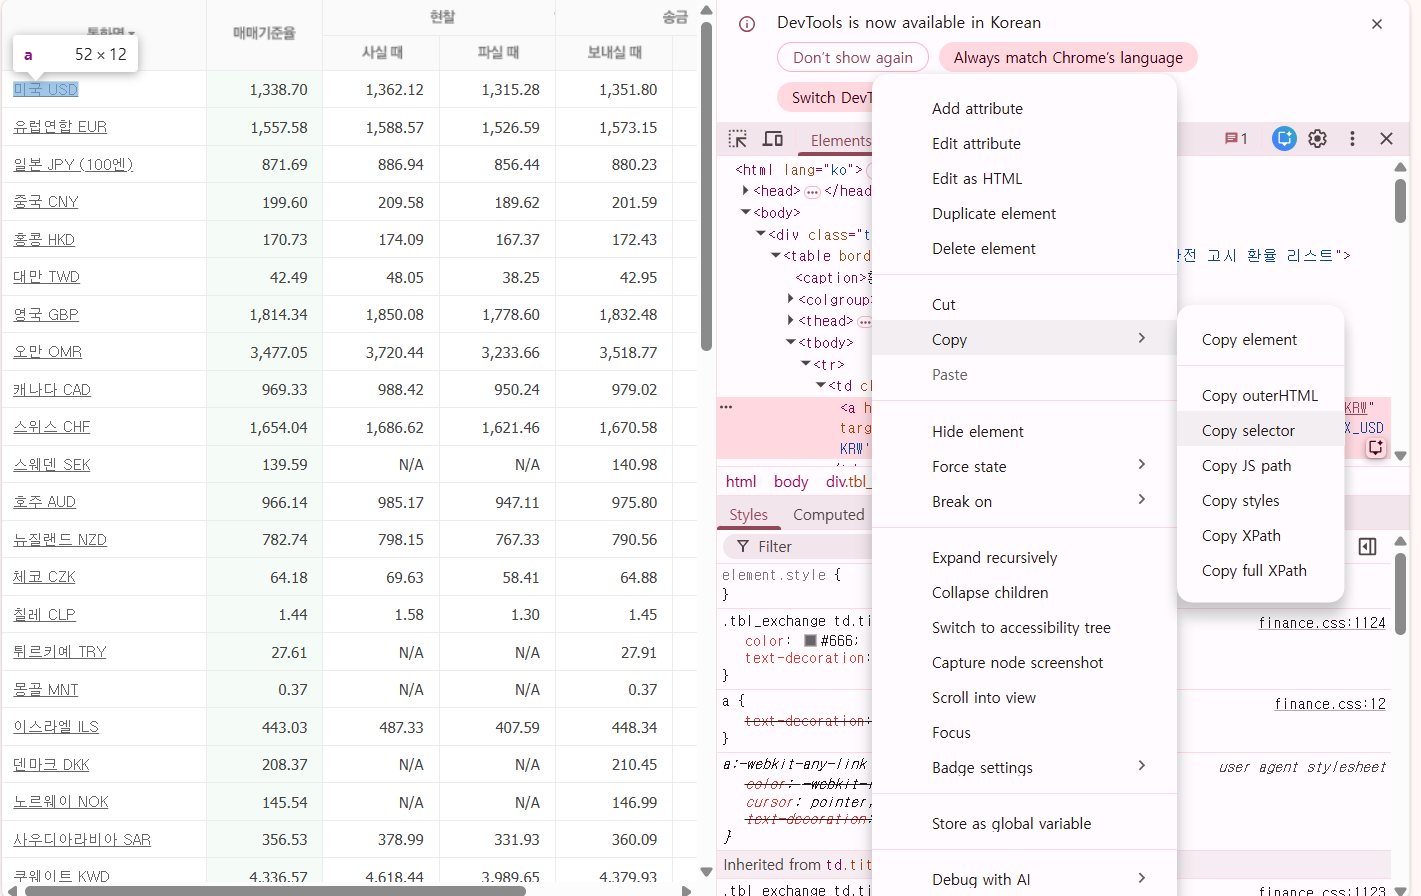

In [56]:
# 반복문으로 리스트 안에 저장
con_lst = [con[i].text.strip() for i in range(len(con))]
rule_lst = [rule[i].text.strip() for i in range(len(rule))]
buy_lst = [buy[i].text.strip() for i in range(len(buy))]
sale_lst = [sale[i].text.strip() for i in range(len(sale))]
print(con_lst)
print(rule_lst)
print(buy_lst)
print(sale_lst)

['미국 USD', '유럽연합 EUR', '일본 JPY (100엔)', '중국 CNY', '홍콩 HKD', '대만 TWD', '영국 GBP', '오만 OMR', '캐나다 CAD', '스위스 CHF', '스웨덴 SEK', '호주 AUD', '뉴질랜드 NZD', '체코 CZK', '칠레 CLP', '튀르키예 TRY', '몽골 MNT', '이스라엘 ILS', '덴마크 DKK', '노르웨이 NOK', '사우디아라비아 SAR', '쿠웨이트 KWD', '바레인 BHD', '아랍에미리트 AED', '요르단 JOD', '이집트 EGP', '태국 THB', '싱가포르 SGD', '말레이시아 MYR', '인도네시아 IDR 100', '카타르 QAR', '카자흐스탄 KZT', '브루나이 BND', '인도 INR', '파키스탄 PKR', '방글라데시 BDT', '필리핀 PHP', '멕시코 MXN', '브라질 BRL', '베트남 VND 100', '남아프리카 공화국 ZAR', '러시아 RUB', '헝가리 HUF', '폴란드 PLN', '스리랑카 LKR', '알제리 DZD', '케냐 KES', '콜롬비아 COP', '탄자니아 TZS', '네팔 NPR', '루마니아 RON', '리비아 LYD', '마카오 MOP', '미얀마 MMK', '에티오피아 ETB', '우즈베키스탄 UZS', '캄보디아 KHR', '피지 FJD']
['1,337.80', '1,556.73', '871.67', '199.47', '170.61', '42.44', '1,813.19', '3,474.71', '968.75', '1,653.34', '139.52', '965.69', '782.28', '64.14', '1.44', '27.59', '0.37', '442.72', '208.26', '145.47', '356.29', '4,333.66', '3,548.26', '364.22', '1,886.88', '26.11', '40.67', '1,058.51', '328.86', '7.64', '367.00', '2.9

In [57]:
# 길이 확인
len(con_lst),len(rule_lst), len(buy_lst), len(sale_lst) 

(58, 58, 58, 58)

In [59]:
# DataFrame으로 변환 !
data = {'통화명' : con_lst, '기준가' : rule_lst, '살 때' : buy_lst, '팔 때' : sale_lst}
import pandas as pd
pd.DataFrame(data)

#환율 경고 시스템등 만들때 사용할 수 있음.

,통화명,기준가,살 때,팔 때
0,미국 USD,"1,337.80","1,361.21","1,314.39"
1,유럽연합 EUR,"1,556.73","1,587.70","1,525.76"
2,일본 JPY (100엔),871.67,886.92,856.42
3,중국 CNY,199.47,209.44,189.50
4,홍콩 HKD,170.61,173.97,167.25
5,대만 TWD,42.44,47.99,38.20
6,영국 GBP,"1,813.19","1,848.90","1,777.48"
7,오만 OMR,"3,474.71","3,717.93","3,231.49"
8,캐나다 CAD,968.75,987.83,949.67
9,스위스 CHF,"1,653.34","1,685.91","1,620.77"
